## Load Data and Libraries

In [1]:
# from google.cloud import bigquery
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, auc, 
                             classification_report, RocCurveDisplay, 
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

df = pd.read_csv("data/cleaned_data.csv", index_col=0)
print("Data Loaded")
print(f"Shape of the data: {df.shape}")

print(f"Columns: {df.columns.tolist()}")
print(f"Data types:\n{df.dtypes}")

Data Loaded
Shape of the data: (34830, 16)
Columns: ['care_unit', 'admission_type', 'admission_location', 'language', 'marital_status', 'race', 'hospital_expire_flag', 'gender', 'age', 'rr_interval', 'qrs_onset', 'qrs_end', 't_end', 'qrs_axis', 't_axis', 'ecg_bucket']
Data types:
care_unit                object
admission_type           object
admission_location       object
language                 object
marital_status           object
race                     object
hospital_expire_flag      int64
gender                    int64
age                       int64
rr_interval             float64
qrs_onset               float64
qrs_end                 float64
t_end                   float64
qrs_axis                float64
t_axis                  float64
ecg_bucket               object
dtype: object


## Exploratory Data Analysis

In [2]:
print("Class distribution:")
print(df[df['hospital_expire_flag'] == 1].shape[0], df[df['hospital_expire_flag'] == 0].shape[0])
print(f"\nMortality rate: {df['hospital_expire_flag'].mean():.2%}")

Class distribution:
4195 30635

Mortality rate: 12.04%


## Preprocessing

In [3]:
categorical_cols = [
    'care_unit', 'admission_type', 'admission_location',
    'language', 'marital_status', 'race',
    'ecg_bucket'
]

numeric_cols = [
    'age','rr_interval',
    'qrs_onset', 'qrs_end',
    't_end','qrs_axis', 't_axis'
]

# Separate features and target variable
y = df['hospital_expire_flag']
X = df[categorical_cols + numeric_cols]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")
print("Data splitted into training and testing sets\n")
print("Training columns:")
print(X_train.columns)   
print("\nFirst 5 rows of the training labels:")
print(y_train.head())

Training set shape: (27864, 14), (27864,)
Testing set shape: (6966, 14), (6966,)
Data splitted into training and testing sets

Training columns:
Index(['care_unit', 'admission_type', 'admission_location', 'language',
       'marital_status', 'race', 'ecg_bucket', 'age', 'rr_interval',
       'qrs_onset', 'qrs_end', 't_end', 'qrs_axis', 't_axis'],
      dtype='object')

First 5 rows of the training labels:
18952    1
11651    0
10459    0
5871     0
26449    0
Name: hospital_expire_flag, dtype: int64


## Modeling

In [4]:
# TODO: One-hot encode categorical variables and standardize numerical features in a pipeline
# Preprocessing for numeric features
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a single column transformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# TODO: Decide which models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42)
}

# TODO: Train and evaluate all models
models_fitted = {}  

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    cv_scores = cross_val_score(
        pipe, X_train, y_train,
        cv=StratifiedKFold(5), scoring='roc_auc'
    )

    pipe.fit(X_train, y_train)
    test_auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])

    models_fitted[name] = pipe

    print(f"{name}:")
    print(f"  CV AUC   = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print(f"  Test AUC = {test_auc:.3f}\n")

Logistic Regression:
  CV AUC   = 0.754 ± 0.003
  Test AUC = 0.756

Random Forest:
  CV AUC   = 0.748 ± 0.007
  Test AUC = 0.750

Gradient Boosting:
  CV AUC   = 0.762 ± 0.004
  Test AUC = 0.766



## Model Evaluation

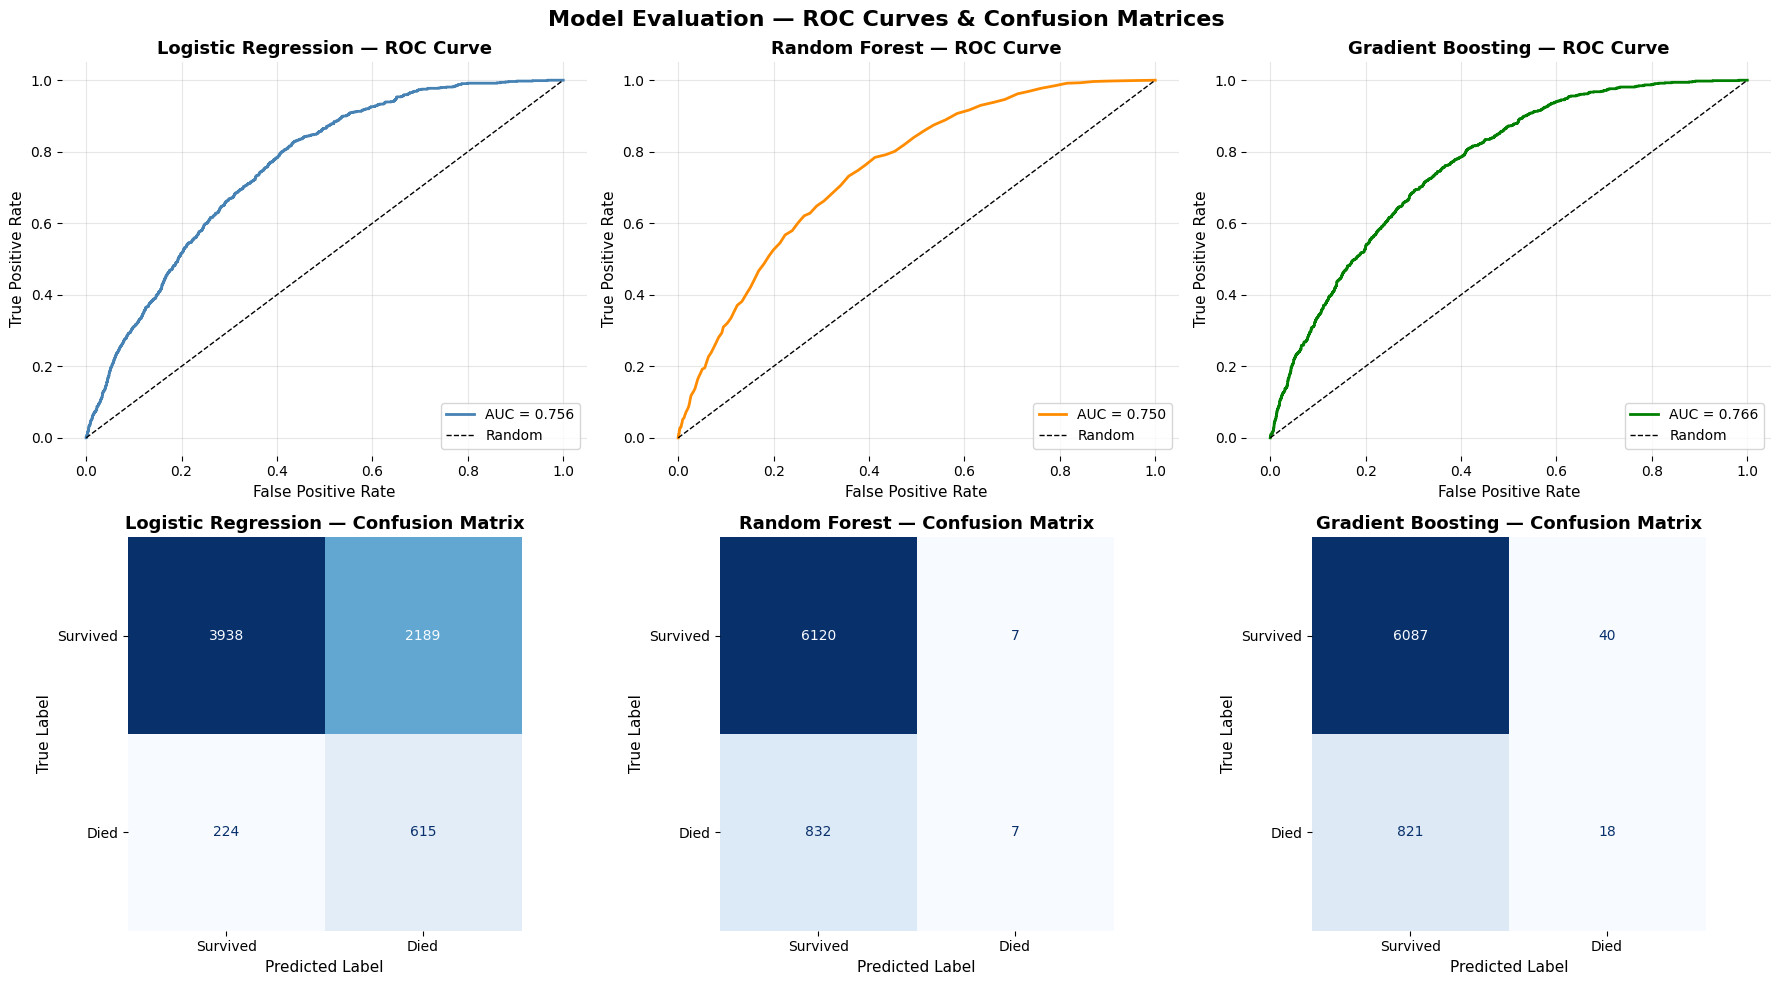

In [5]:
# ROC Curves and Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

colors = ['steelblue', 'darkorange', 'green']

for i, ((name, pipe), color) in enumerate(zip(models_fitted.items(), colors)):
    
    # ── Top Row: ROC Curves ──
    ax_roc = axes[0, i]
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    ax_roc.plot(fpr, tpr, color=color, lw=2,
                label=f"AUC = {roc_auc:.3f}")
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    ax_roc.set_xlabel('False Positive Rate', fontsize=11)
    ax_roc.set_ylabel('True Positive Rate', fontsize=11)
    ax_roc.set_title(f'{name} — ROC Curve', fontsize=13, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=10)
    ax_roc.grid(alpha=0.3)
    for spine in ax_roc.spines.values():
        spine.set_visible(False)

    # ── Bottom Row: Confusion Matrices ──
    ax_cm = axes[1, i]
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Survived', 'Died']
    )
    disp.plot(ax=ax_cm, colorbar=False, cmap='Blues')
    ax_cm.set_title(f'{name} — Confusion Matrix', fontsize=13, fontweight='bold')
    ax_cm.set_xlabel('Predicted Label', fontsize=11)
    ax_cm.set_ylabel('True Label', fontsize=11)
    for spine in ax_cm.spines.values():
        spine.set_visible(False)

plt.suptitle('Model Evaluation — ROC Curves & Confusion Matrices',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sanity_outputs/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance

Total features after encoding: 90
['age', 'rr_interval', 'qrs_onset', 'qrs_end', 't_end', 'qrs_axis', 't_axis', 'care_unit_ccu', 'care_unit_cvicu', 'care_unit_micu', 'care_unit_micu_sicu', 'care_unit_neuro', 'care_unit_other', 'care_unit_sicu', 'care_unit_tsicu', 'admission_type_ambulatory_observation', 'admission_type_direct_emer', 'admission_type_direct_observation', 'admission_type_elective', 'admission_type_eu_observation', 'admission_type_ew_emer', 'admission_type_observation_admit', 'admission_type_surgical_same_day_admission', 'admission_type_urgent', 'admission_location_ambulatory_surgery_transfer', 'admission_location_clinic_referral', 'admission_location_emergency_room', 'admission_location_information_not_available', 'admission_location_internal_transfer_to_or_from_psych', 'admission_location_pacu', 'admission_location_physician_referral', 'admission_location_procedure_site', 'admission_location_transfer_from_hospital', 'admission_location_transfer_from_skilled_nursing_facil

,feature,importance
0,rr_interval,0.101719
1,age,0.098727
2,t_end,0.090439
3,t_axis,0.089675
4,qrs_axis,0.087432
5,qrs_end,0.081834
6,qrs_onset,0.072549
7,care_unit_cvicu,0.040275
8,ecg_bucket_normal_sinus,0.017728
9,care_unit_micu,0.015139


<Figure size 1000x600 with 0 Axes>

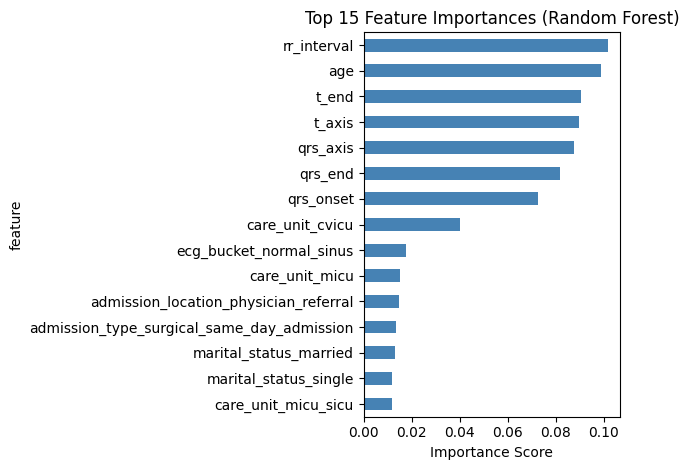

In [6]:
# Feature Importance Analysis for Random Forest
# Get feature names after one-hot encoding
cat_feature_names = (
    preprocessor
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_cols)
    .tolist()
)

all_feature_names = numeric_cols + cat_feature_names
print(f"Total features after encoding: {len(all_feature_names)}")
print(all_feature_names)

# Use the already fitted Random Forest pipeline
rf_pipe = models_fitted['Random Forest']  # from previous step
rf_model = rf_pipe.named_steps['model']

# Build importance dataframe
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

display(importance_df.head(15))

# Plot top 15 features
plt.figure(figsize=(10, 6))
importance_df.head(15).plot(
    kind='barh', x='feature', y='importance',
    legend=False, color='steelblue'
)
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('sanity_outputs/feature_importance.png', dpi=150)
plt.show()

In [7]:
# WARNING: Take a while to run SHAP on the full test set. Consider using a subset for faster results.
# import shap

# # Transform test data using fitted preprocessor
# X_test_transformed = preprocessor.transform(X_test)

# # Use a subset of the test data for SHAP to speed up computation
# sample_size = 500
# X_shap = X_test_transformed[:sample_size]

# # ── Random Forest SHAP ──
# rf_model = models_fitted['Random Forest'].named_steps['model']
# explainer_rf = shap.TreeExplainer(rf_model)
# shap_values_rf = explainer_rf.shap_values(X_shap)

# # For binary classification, shap_values[1] = positive class (died)
# shap_vals = shap_values_rf[1] if isinstance(shap_values_rf, list) else shap_values_rf

# # Summary plot — shows most impactful features
# plt.figure()
# shap.summary_plot(
#     shap_vals,
#     X_test_transformed,
#     feature_names=all_feature_names,
#     show=False
# )
# plt.title('SHAP Summary Plot — Random Forest')
# plt.tight_layout()
# plt.savefig('shap_summary.png', dpi=150)
# plt.show()

# Bar plot — mean absolute SHAP values
# plt.figure()
# shap.summary_plot(
#     shap_vals,
#     X_test_transformed,
#     feature_names=all_feature_names,
#     plot_type='bar',
#     show=False
# )
# plt.title('SHAP Feature Importance (Mean |SHAP|)')
# plt.tight_layout()
# plt.savefig('shap_bar.png', dpi=150)
# plt.show()